# SAX mit Networx Experiment

In diesem Experiment habe ich ausprobiert, aus einer SAX-diskretisierte Zeitreihe beliebig lange N-Gramme zu extrahieren und diese anschließend in einem gerichteten Graphen anzuordnen. Kann dieser Graph dabei helfen, Motive und Abfolgen in der Zeitreihe zu erkennen und "typische" Muster zu extrahieren?

In [1]:
from matplotlib import pyplot as plt
from networkx import DiGraph
from numpy import array, percentile
from networkx import get_edge_attributes, draw_networkx_edge_labels
from networkx import circular_layout, draw
from saxpy.znorm import znorm
from saxpy.alphabet import cuts_for_asize
from saxpy.sax import ts_to_string
from collections import Counter
from numpy.random import normal
from pandas import read_csv


N_GRAM_SIZE = 2
TS_SIZE = 100

## Gnerate a Random Timeseries (did not work as no patterns)

In [2]:
deltas = normal(0, 1, TS_SIZE)
current_value = 120
timeseries = []
for i in range(TS_SIZE):
    timeseries.append(current_value + deltas[i])

## Import the Elevator Timeseries

In [3]:
timeseries = read_csv("../data/motiv_240.csv", usecols=[1])

## Discretizise the Timeseries

In [4]:
char_timeseries = ts_to_string(znorm(timeseries["sensor"]), cuts_for_asize(5))
chars = sorted(list(set(list(char_timeseries))))
to_num = lambda char_timeseries: [chars.index(c) for c in char_timeseries]
to_pairs = lambda char_timeseries: [char_timeseries[i:i+N_GRAM_SIZE] for i, _ in enumerate(char_timeseries)][:-N_GRAM_SIZE]

## Plot the Timeseries

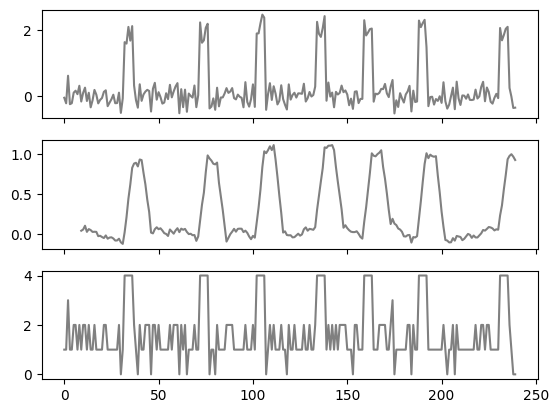

In [19]:
fig, ax = plt.subplots(ncols=1, nrows=3, sharex=True)
ax[0].plot(timeseries, "grey")
ax[1].plot(timeseries.rolling(10).mean(), "grey")
ax[2].plot(to_num(char_timeseries), "grey")
plt.show()

In [20]:
snippets = to_pairs(char_timeseries)

edges = []
for i in range(len(snippets)-1):
    edges.append((snippets[i], snippets[i+1]))

weighted_edges = [(item[0], item[1], Counter(edges)[item]) for item in Counter(edges)]

G = DiGraph()
for edge in weighted_edges:
    G.add_edge(edge[0], edge[1], weight=edge[2])

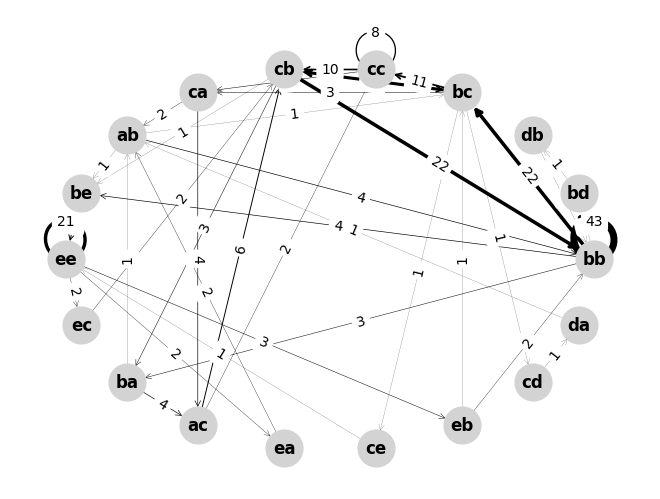

In [14]:
weights = [G[u][v]['weight'] for u, v in G.edges()]
weights = array(weights) / max(weights) * 5

options = {
    'node_color': 'lightgrey',
    'node_size': 700,
    "font_weight": 'bold',
    #"connectionstyle": 'arc3, rad=0.2',
    "arrowstyle": '->'
}

edge_labels = get_edge_attributes(G, 'weight')


pos = circular_layout(G)
draw(G, pos, with_labels=True, width=weights, **options)
draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()

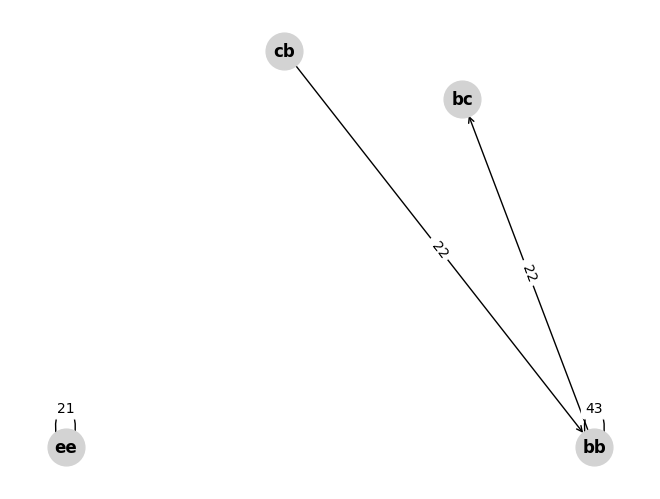

In [15]:

weights = [d['weight'] for u, v, d in G.edges(data=True)]
threshold = percentile(weights, 90)
top_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] >= threshold]

top_nodes = set([n for edge in top_edges for n in edge])
subgraph = G.subgraph(top_nodes).edge_subgraph(top_edges)
edge_labels = get_edge_attributes(subgraph, 'weight')

pos = circular_layout(G)
draw(subgraph, pos, with_labels=True, **options)
draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels)
plt.show()